<a href="https://colab.research.google.com/github/iqbaal24/PCVK_2026/blob/main/Week7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 7 - Modul 6: Filter Spasial
Praktikum Pengolahan Citra dan Visi Komputer.

**Cara pakai di Colab:** upload folder `gambar` (berisi `astronaut.png`, `astronaut_blur.png`, `camera_gray.png`) ke Colab (panel kiri > Files), atau taruh di Google Drive lalu ubah `FOLDER` di sel berikut.

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import math

# Jika memakai Google Drive, hapus tanda # di 2 baris bawah lalu ubah FOLDER
from google.colab import drive
drive.mount('/content/drive')
FOLDER = '/content/drive/MyDrive/PCVK'
def tampil(images, titles, figsize=(15,5)):
    plt.figure(figsize=figsize)
    for i,(img,t) in enumerate(zip(images,titles)):
        plt.subplot(1,len(images),i+1)
        if img.ndim==2: plt.imshow(img,cmap='gray',vmin=0,vmax=255)
        else: plt.imshow(cv.cvtColor(img,cv.COLOR_BGR2RGB))
        plt.title(t); plt.axis('off')
    plt.show()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## D.1 Konvolusi tanpa library
Fungsi ini mengikuti algoritma di modul: setiap piksel hasil adalah jumlah perkalian kernel dengan piksel tetangga. Parameter: citra, kernel, stride, dan padding (diisi nilai 0). Tidak memakai `cv.filter2D` atau fungsi konvolusi OpenCV.

In [13]:
def convolution2d(image, kernel, stride=1, padding=0):
    image = image.astype(np.float32)
    if padding > 0:
        image = np.pad(image, padding, mode='constant', constant_values=0)
    kh, kw = kernel.shape
    H, W = image.shape
    out_h = (H - kh) // stride + 1
    out_w = (W - kw) // stride + 1
    hasil = np.zeros((out_h, out_w), dtype=np.float32)
    # jumlahkan kernel[k1,k2] * piksel yang tergeser (sama dengan algoritma 4 loop di modul)
    for k1 in range(kh):
        for k2 in range(kw):
            potongan = image[k1:k1+out_h*stride:stride, k2:k2+out_w*stride:stride]
            hasil += kernel[k1, k2] * potongan
    return hasil

def ke_uint8(x):
    return np.clip(x, 0, 255).astype(np.uint8)

# Uji dengan contoh di modul: citra 5x5 dan kernel 3x3, hasilnya harus sama dengan modul
f = np.array([[4,4,3,5,4],[6,6,5,5,2],[5,6,6,6,2],[6,7,5,5,3],[3,5,2,4,4]])
k = np.array([[0,-1,0],[-1,4,-1],[0,-1,0]])
print(convolution2d(f, k))   # hasil: [[3,0,2],[0,2,6],[6,0,2]] -> sama dengan langkah 1-5 di modul (3 0 2 / 0 2 6 / 6 0 2)

[[3. 0. 2.]
 [0. 2. 6.]
 [6. 0. 2.]]


## D.2 Load citra dan ubah ke grayscale

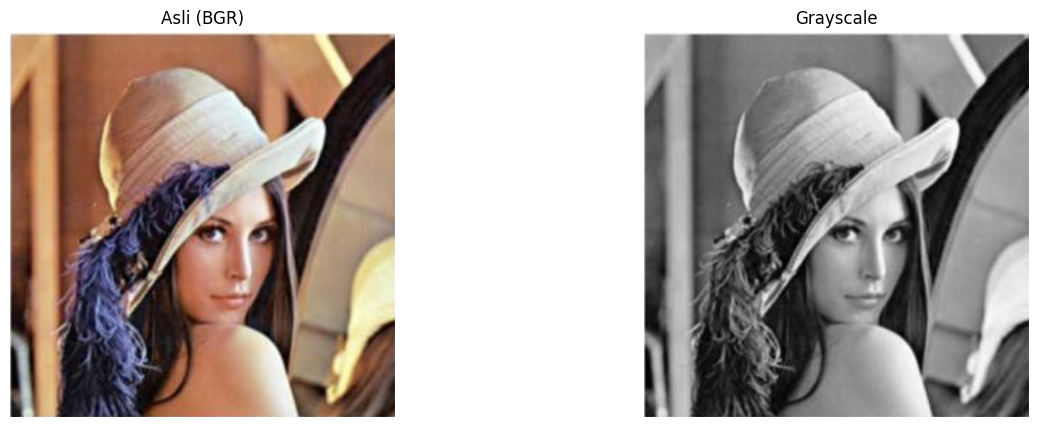

In [17]:
img = cv.imread(f'{FOLDER}/lena.jpg')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
tampil([img, img_gray], ['Asli (BGR)', 'Grayscale'])

## D.3 Image filter: Average, Low Pass, High Pass, Sharpen, Emboss, Left Sobel, Canny (kernel), Gaussian 21x21

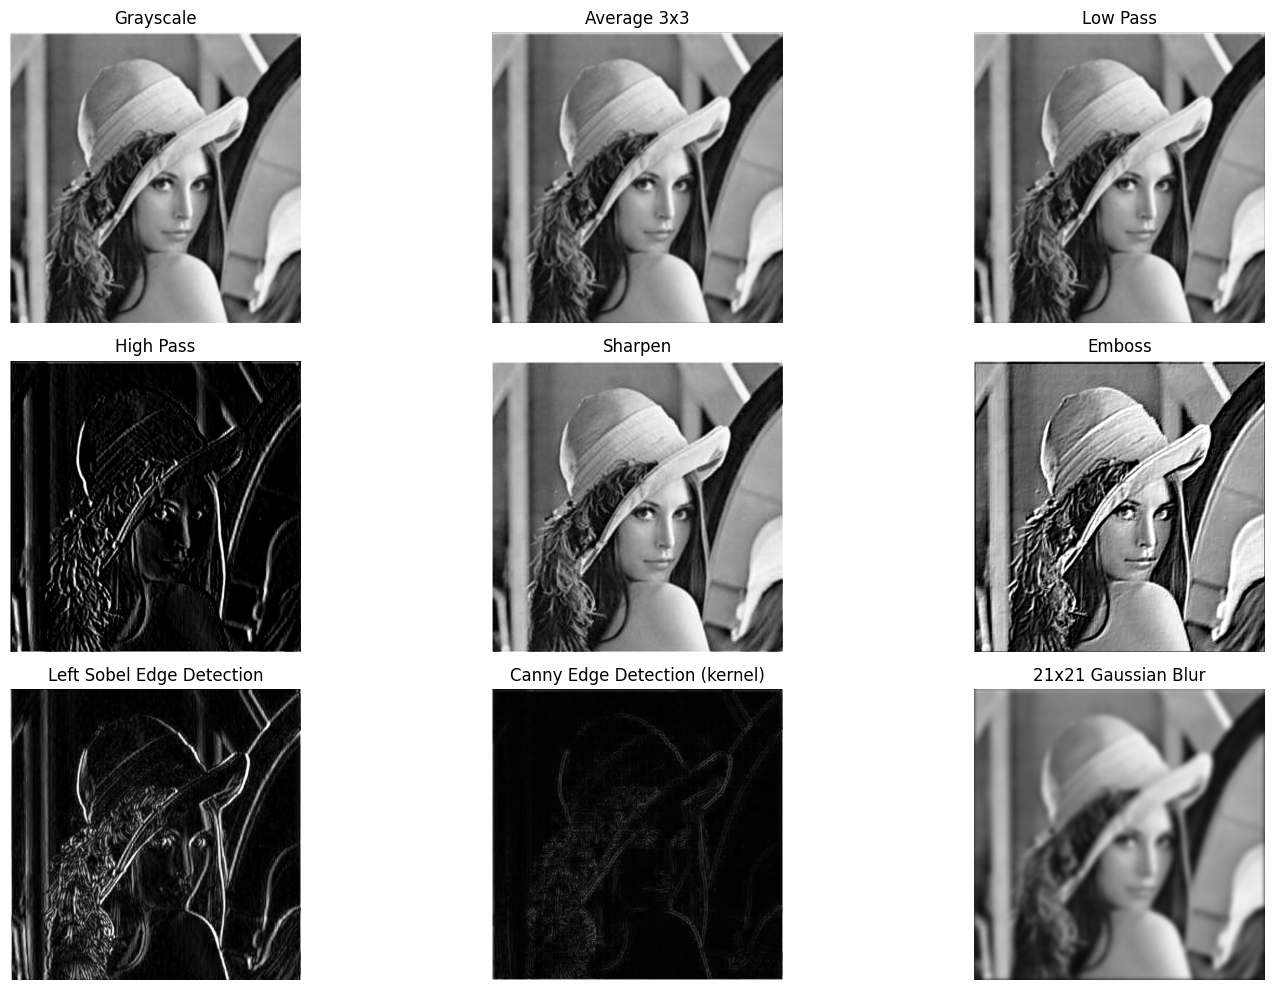

In [18]:
kernels = {
 'Average 3x3':   np.ones((3,3))/9,
 'Low Pass':      np.array([[1,1,1],[1,4,1],[1,1,1]])/12,
 'High Pass':     np.array([[-1,0,1],[-1,0,3],[-3,0,1]]),
 'Sharpen':       np.array([[0,-1,0],[-1,5,-1],[0,-1,0]]),
 'Emboss':        np.array([[-2,-1,0],[-1,1,1],[0,1,2]]),
 'Left Sobel Edge Detection': np.array([[1,0,-1],[2,0,-2],[1,0,-1]]),
 'Canny Edge Detection (kernel)': np.array([[-1,-1,-1],[-1,8,-1],[-1,-1,-1]]),
}

# Gaussian 21x21 (kode dari modul)
kernel_size = 21
sigma = math.sqrt(kernel_size)
gk = cv.getGaussianKernel(kernel_size, sigma)
kernels['21x21 Gaussian Blur'] = gk @ gk.transpose()

hasil = {}
for nama, kern in kernels.items():
    pad = kern.shape[0]//2          # padding agar ukuran hasil sama dengan citra
    h = convolution2d(img_gray, kern, stride=1, padding=pad)
    hasil[nama] = ke_uint8(np.abs(h)) if 'Sobel' in nama or 'Canny' in nama else ke_uint8(h)

plt.figure(figsize=(16,10))
plt.subplot(3,3,1); plt.imshow(img_gray,cmap='gray'); plt.title('Grayscale'); plt.axis('off')
for i,(nama,h) in enumerate(hasil.items()):
    plt.subplot(3,3,i+2); plt.imshow(h,cmap='gray',vmin=0,vmax=255); plt.title(nama); plt.axis('off')
plt.tight_layout(); plt.show()

## E. Filter library dan filter modern
### Percobaan 1: Gaussian, Sharpen, Canny (filter2D OpenCV)

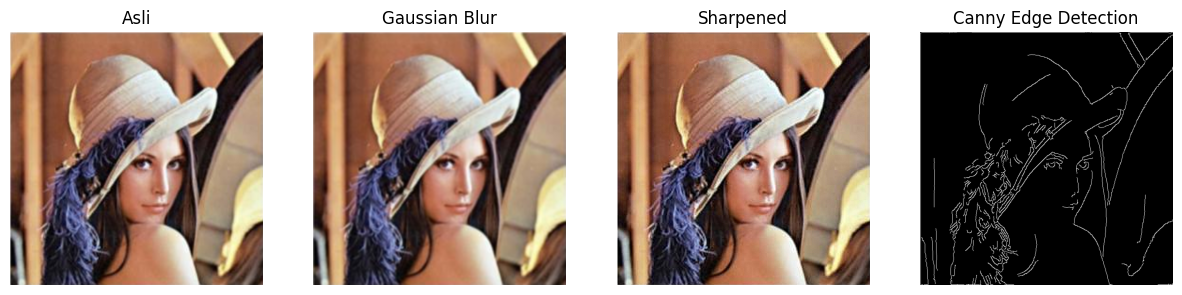

In [19]:
blur = cv.GaussianBlur(img, (7,7), 1)
edges = cv.Canny(cv.cvtColor(img, cv.COLOR_BGR2GRAY), 100, 200)
sharpen_kernel = np.array([[0,-1,0],[-1,5,-1],[0,-1,0]])
sharpened = cv.filter2D(img, -1, sharpen_kernel)
tampil([img, blur, sharpened, edges], ['Asli','Gaussian Blur','Sharpened','Canny Edge Detection'])

### Percobaan 2: Bilateral dan Edge Preserving Filter

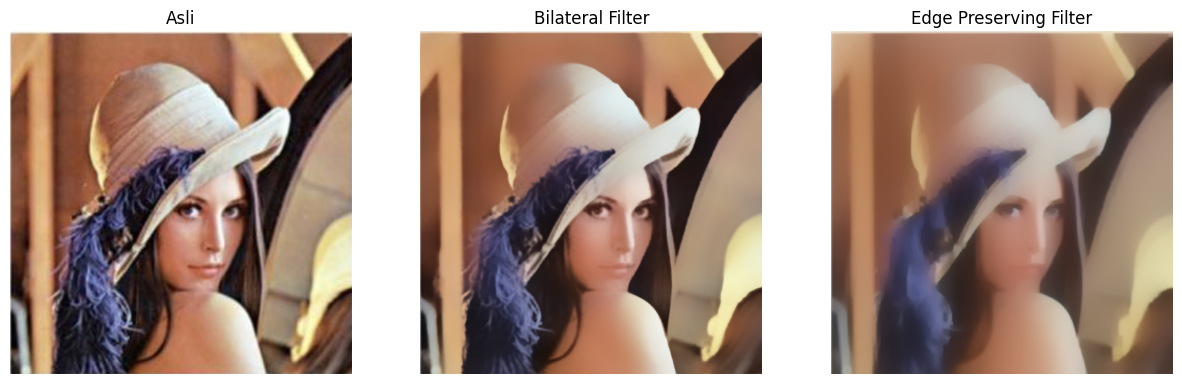

In [20]:
bilateral = cv.bilateralFilter(img, 50, 100, 100)
edge_preserve = cv.edgePreservingFilter(img, flags=1, sigma_s=100, sigma_r=0.9)
tampil([img, bilateral, edge_preserve], ['Asli','Bilateral Filter','Edge Preserving Filter'])

### Percobaan 3: Feature map CNN
Butuh PyTorch (sudah tersedia di Colab). Jalankan beberapa kali: bobot kernel diacak tiap kali model dibuat, jadi feature map berbeda-beda.

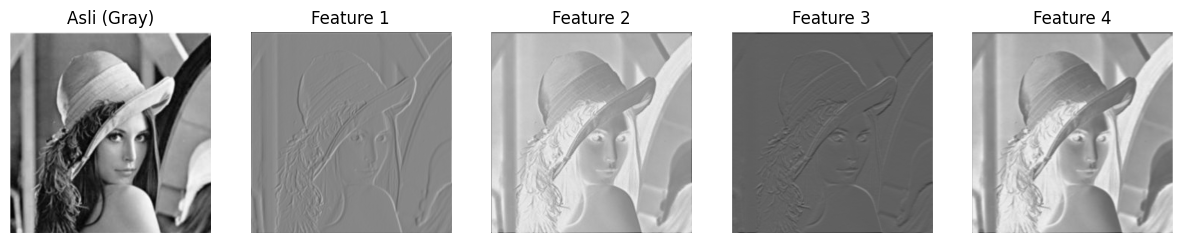

In [21]:
try:
    import torch, torch.nn as nn
    class SimpleCNN(nn.Module):
        def __init__(self):
            super().__init__()
            self.conv1 = nn.Conv2d(1, 4, kernel_size=3, stride=1, padding=1)
        def forward(self, x): return self.conv1(x)
    model = SimpleCNN()
    img_tensor = torch.tensor(img_gray, dtype=torch.float32).unsqueeze(0).unsqueeze(0) / 255.0
    with torch.no_grad(): features = model(img_tensor)
    fm = [features[0,i].numpy() for i in range(features.shape[1])]
    plt.figure(figsize=(15,4))
    for i,m in enumerate([img_gray/255.0]+fm):
        plt.subplot(1,5,i+1); plt.imshow(m,cmap='gray'); plt.axis('off')
        plt.title('Asli (Gray)' if i==0 else f'Feature {i}')
    plt.show()
except ImportError:
    print('PyTorch tidak ditemukan. Jalankan di Google Colab.')

**Kesimpulan Percobaan 3:** Tiap kali kode dijalankan, bobot kernel `Conv2d` dibuat acak, sehingga keempat feature map berbeda (ada yang menonjolkan tepi, ada yang hanya meredupkan atau menghaluskan). Pada CNN yang sudah dilatih, bobot kernel tidak acak lagi, tetapi dipelajari dari data agar menonjolkan pola yang berguna. Jadi filter CNN pada dasarnya sama dengan kernel konvolusi di modul ini, bedanya nilai kernelnya dipelajari otomatis, bukan ditentukan manual.

### Percobaan 4-7: Filter Beauty, Vintage, Cartoon, Malam, Pagi dan Kabut

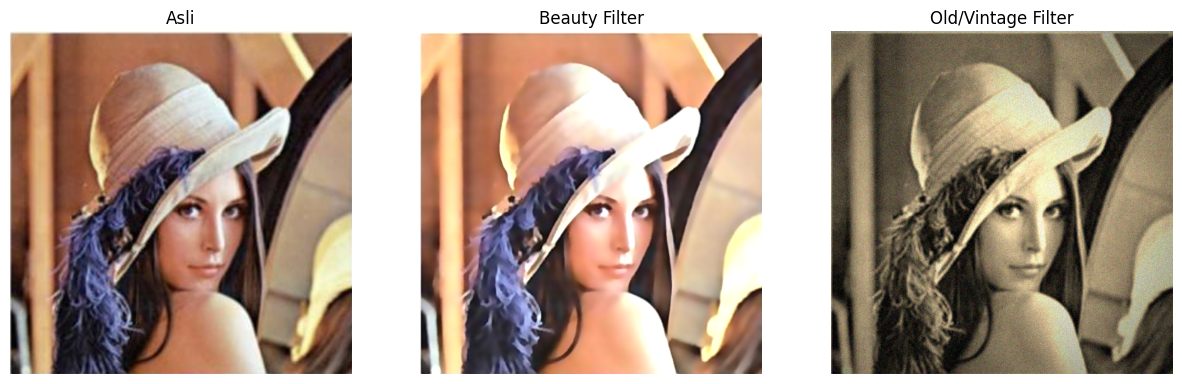

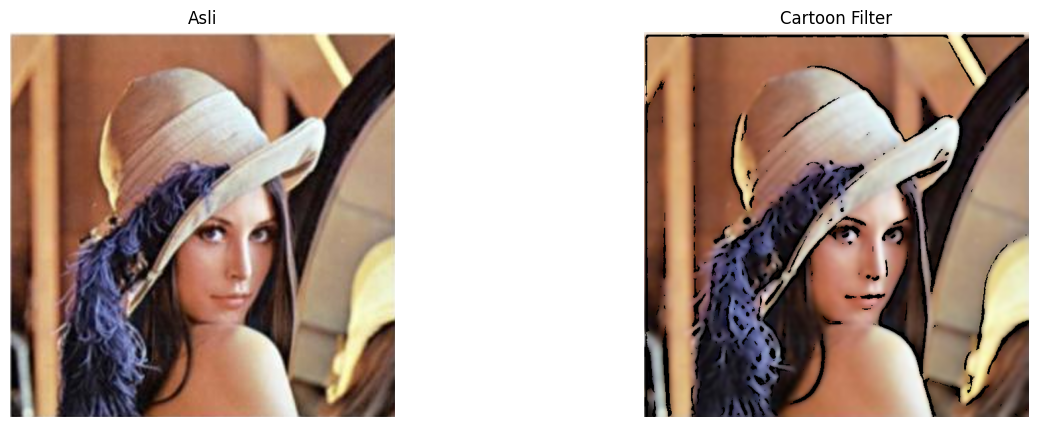

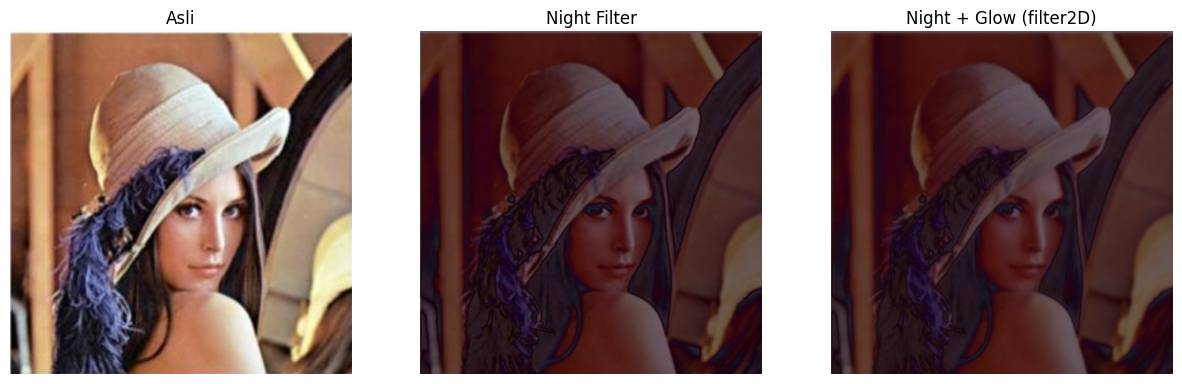

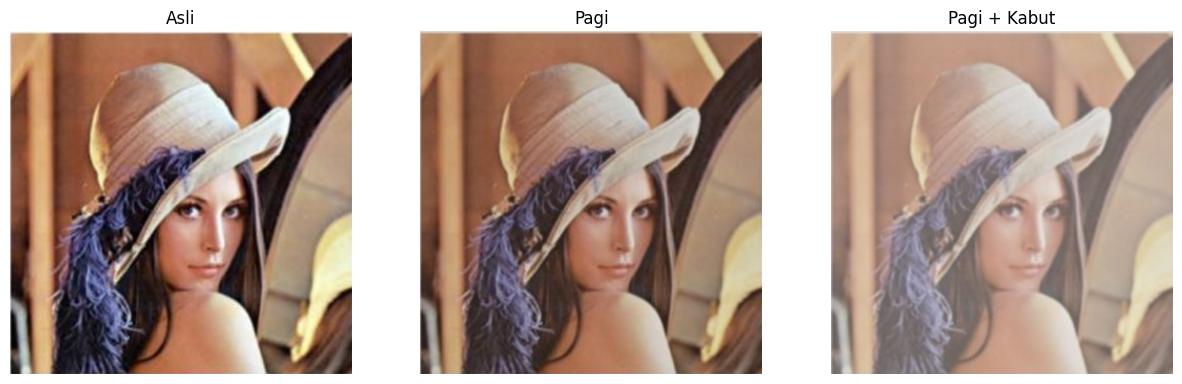

In [22]:
# Beauty
smooth = cv.bilateralFilter(img, d=15, sigmaColor=75, sigmaSpace=75)
gaussian = cv.GaussianBlur(smooth, (0,0), 3)
sharp = cv.addWeighted(smooth, 1.5, gaussian, -0.5, 0)
beauty = cv.convertScaleAbs(sharp, alpha=1.2, beta=15)

# Vintage
sepia_kernel = np.array([[0.272,0.534,0.131],[0.349,0.686,0.168],[0.393,0.769,0.189]])
sepia = np.clip(cv.transform(img, sepia_kernel), 0, 255).astype(np.uint8)
rows, cols = img.shape[:2]
kx = cv.getGaussianKernel(cols, cols*0.6); ky = cv.getGaussianKernel(rows, rows*0.6)
mask = (ky * kx.T); mask = mask / mask.max()
vignette = np.copy(sepia)
for i in range(3): vignette[:,:,i] = vignette[:,:,i] * mask
noise = np.random.normal(0, 15, vignette.shape).astype(np.int16)
old_img = np.clip(vignette.astype(np.int16) + noise, 0, 255).astype(np.uint8)
tampil([img, beauty, old_img], ['Asli','Beauty Filter','Old/Vintage Filter'])

# Cartoon (percobaan 5)
g = cv.medianBlur(cv.cvtColor(img, cv.COLOR_BGR2GRAY), 7)
e = cv.adaptiveThreshold(g, 255, cv.ADAPTIVE_THRESH_MEAN_C, cv.THRESH_BINARY, 9, 9)
c = cv.bilateralFilter(img, d=9, sigmaColor=200, sigmaSpace=200)
tampil([img, cv.bitwise_and(c, c, mask=e)], ['Asli','Cartoon Filter'])

# Malam (percobaan 6)
night = cv.convertScaleAbs(img, alpha=0.6, beta=-40)
night = cv.addWeighted(night, 0.8, np.full_like(night, (50,0,100)), 0.2, 0)
glow = cv.filter2D(night, -1, np.ones((15,15), np.float32)/225)
night_glow = cv.addWeighted(night, 0.7, glow, 0.3, 0)
tampil([img, night, night_glow], ['Asli','Night Filter','Night + Glow (filter2D)'])

# Pagi dan kabut (percobaan 7)
soft = cv.convertScaleAbs(img, alpha=0.9, beta=20)
pagi = cv.addWeighted(soft, 0.8, np.full_like(soft, (40,70,120)), 0.2, 0)
k3 = cv.getGaussianKernel(3,3); k3 = k3 @ k3.T
kabut = cv.filter2D(pagi, -1, k3)
kabut = cv.addWeighted(kabut, 0.7, np.full_like(pagi, 255), 0.3, 0)
tampil([img, pagi, kabut], ['Asli','Pagi','Pagi + Kabut'])

# Tugas Praktikum

## Tugas 1: Mean Filter vs Median Filter pada noise Salt and Pepper

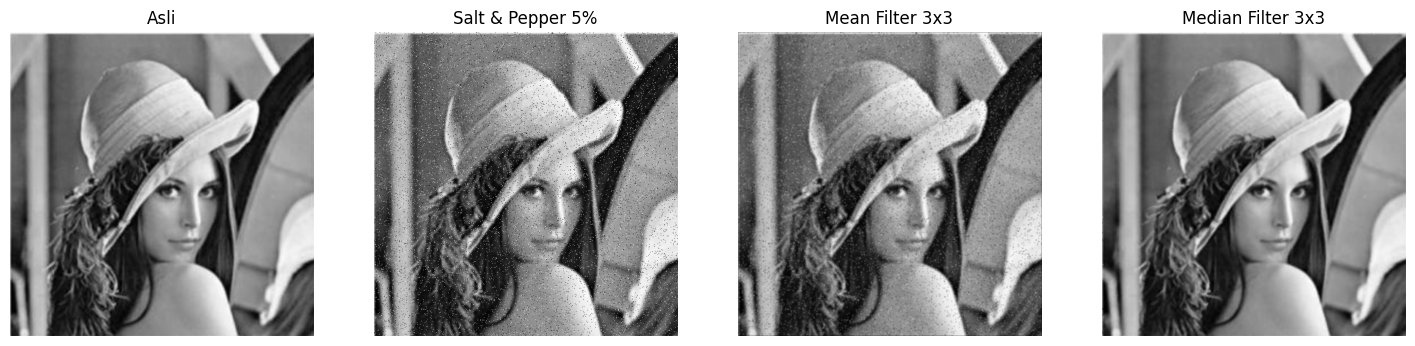

PSNR noisy : 18.1 dB
PSNR mean  : 26.06 dB
PSNR median: 43.09 dB


In [23]:
def tambah_salt_pepper(gray, jumlah=0.05, seed=0):
    rng = np.random.default_rng(seed)
    noisy = gray.copy()
    r = rng.random(gray.shape)
    noisy[r < jumlah/2] = 0            # pepper (hitam)
    noisy[r > 1 - jumlah/2] = 255      # salt (putih)
    return noisy

def psnr(a, b):
    mse = np.mean((a.astype(np.float32)-b.astype(np.float32))**2)
    return 10*np.log10(255**2/mse)

noisy = tambah_salt_pepper(img_gray, 0.05)
mean3 = ke_uint8(convolution2d(noisy, np.ones((3,3))/9, 1, 1))   # Mean filter 3x3 (buatan sendiri)
median3 = cv.medianBlur(noisy, 3)                                 # Median filter 3x3

tampil([img_gray, noisy, mean3, median3], ['Asli','Salt & Pepper 5%','Mean Filter 3x3','Median Filter 3x3'], (18,5))
print('PSNR noisy :', round(psnr(img_gray, noisy),2), 'dB')
print('PSNR mean  :', round(psnr(img_gray, mean3),2), 'dB')
print('PSNR median:', round(psnr(img_gray, median3),2), 'dB')

**Analisis:** Noise salt and pepper berupa piksel yang nilainya ekstrem (0 atau 255). Mean filter menghitung rata-rata 9 piksel, jadi satu piksel ekstrem ikut menarik rata-rata ke atas atau ke bawah. Akibatnya bintik tidak hilang, hanya berubah menjadi noda abu-abu yang lebih lebar, dan gambar ikut menjadi buram. Median filter mengurutkan 9 nilai lalu mengambil nilai tengah. Karena piksel noise berada di ujung urutan (paling kecil atau paling besar), nilainya langsung terbuang dan tidak ikut menentukan hasil. Itulah sebabnya hasil median jauh lebih bersih dan tepi objek tetap tajam. Nilai PSNR yang lebih tinggi pada median juga menunjukkan hasilnya lebih dekat ke citra asli.

## Tugas 2: Ukuran kernel terbaik untuk sharpening (3x3 vs 5x5)

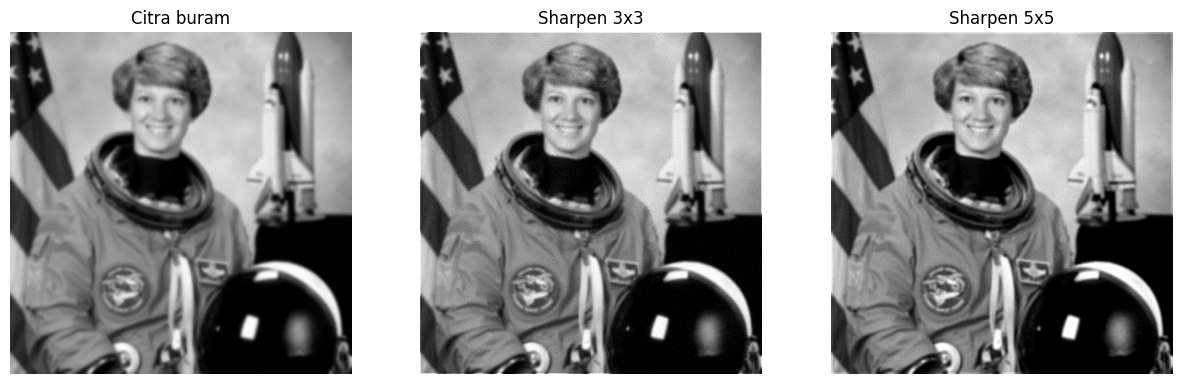

Buram  | kejelasan tepi:   37.00 | noise area datar: 0.95
3x3    | kejelasan tepi:   42.40 | noise area datar: 4.07
5x5    | kejelasan tepi:   45.58 | noise area datar: 0.95


In [24]:
blurry = cv.imread(f'{FOLDER}/astronaut_blur.png', cv.IMREAD_GRAYSCALE)

k3 = np.array([[0,-1,0],[-1,5,-1],[0,-1,0]], dtype=np.float32)
k5 = np.array([[-1,-1,-1,-1,-1],
               [-1, 2, 2, 2,-1],
               [-1, 2, 8, 2,-1],
               [-1, 2, 2, 2,-1],
               [-1,-1,-1,-1,-1]], dtype=np.float32) / 8.0   # jumlah elemen = 1, kecerahan tetap

s3 = ke_uint8(convolution2d(blurry, k3, 1, 1))
s5 = ke_uint8(convolution2d(blurry, k5, 1, 2))
tampil([blurry, s3, s5], ['Citra buram','Sharpen 3x3','Sharpen 5x5'])

def kejelasan_tepi(x):   # rata-rata kekuatan gradien (Sobel) setelah dihaluskan sedikit; makin besar = tepi makin jelas
    h = cv.GaussianBlur(x, (0,0), 1.0)
    gx = cv.Sobel(h, cv.CV_32F, 1, 0); gy = cv.Sobel(h, cv.CV_32F, 0, 1)
    return float(np.mean(np.sqrt(gx**2 + gy**2)))

# cari otomatis blok 40x40 paling datar pada citra buram (tempat noise paling mudah terlihat)
best, pos = 1e9, (0,0)
for r in range(0, 512-40, 20):
    for c in range(0, 512-40, 20):
        v = blurry[r:r+40, c:c+40].std()
        if v < best: best, pos = v, (r,c)
r0, c0 = pos
def kadar_noise(x):      # simpangan baku di blok datar tadi; makin besar = makin berisik
    return float(np.std(x[r0:r0+40, c0:c0+40].astype(np.float32)))

for nama, x in [('Buram',blurry),('3x3',s3),('5x5',s5)]:
    print(f'{nama:6s} | kejelasan tepi: {kejelasan_tepi(x):7.2f} | noise area datar: {kadar_noise(x):.2f}')

**Evaluasi (hasil dengan citra astronaut_blur.png):** Kejelasan tepi naik dari 37,0 (buram) menjadi 42,4 dengan kernel 3x3 dan 45,6 dengan kernel 5x5. Namun noise di area datar naik cukup besar pada kernel 3x3 (dari 0,95 menjadi 4,07, sekitar 4 kali lipat), sedangkan pada kernel 5x5 hampir tidak berubah (0,95). Penyebabnya, kernel 3x3 punya bobot tengah besar (5) dan bobot tetangga negatif tajam, sehingga bintik kecil ikut dikuatkan. Kernel 5x5 membagi pengaruh ke 24 tetangga dengan bobot kecil, jadi lebih halus dan noise tidak ikut naik. Kesimpulan: untuk penggunaan sehari-hari kernel 5x5 lebih optimal karena tepi lebih jelas dengan noise lebih rendah. Kernel 3x3 cocok bila ingin penajaman yang kuat dan cepat pada foto yang bersih. Catatan: angka bisa sedikit berbeda jika Anda memakai gambar lain, jadi cocokkan dengan angka yang keluar di notebook Anda.

## Tugas 3: Filter Kartun Sederhana

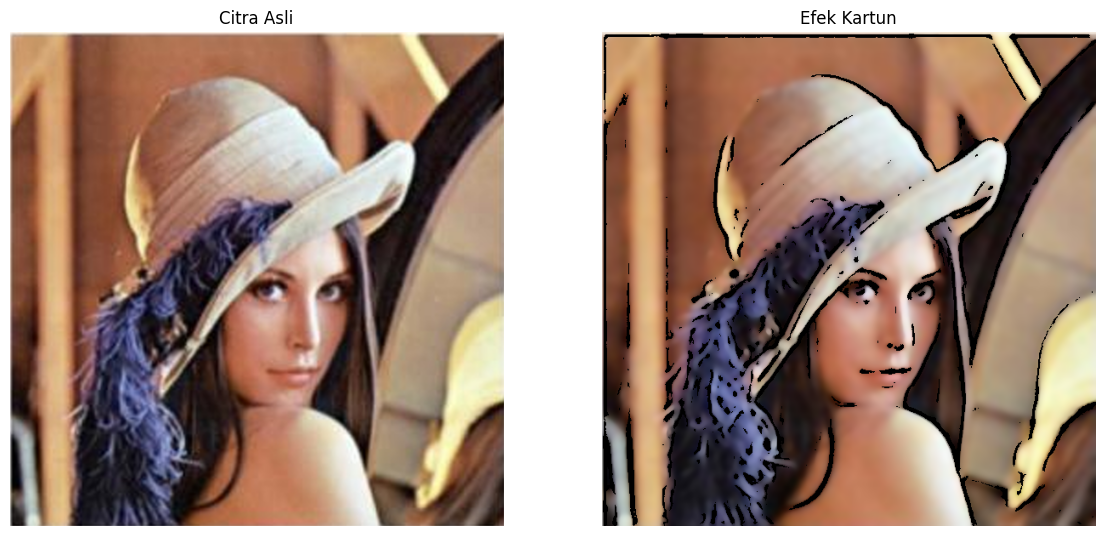

In [25]:
def kartun(image):
    # 1. Penghalusan warna dengan Bilateral Filter agar area warna rata
    warna = image.copy()
    for _ in range(2):                       # diulang agar warna lebih rata
        warna = cv.bilateralFilter(warna, d=9, sigmaColor=75, sigmaSpace=75)
    # 2. Deteksi garis tepi dengan Adaptive Thresholding
    gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
    gray = cv.medianBlur(gray, 7)
    garis = cv.adaptiveThreshold(gray, 255, cv.ADAPTIVE_THRESH_MEAN_C, cv.THRESH_BINARY, 9, 9)
    # 3. Gabungkan: garis (hitam) menimpa warna lewat operasi logika AND
    return cv.bitwise_and(warna, warna, mask=garis)

hasil_kartun = kartun(img)
tampil([img, hasil_kartun], ['Citra Asli','Efek Kartun'], (14,7))